# Proyecto Sprint 16: Predicción de Pedidos de Taxi

## Descripción del Proyecto
La compañía Sweet Lift Taxi busca atraer más conductores durante las horas pico mediante la predicción de la demanda de taxis para la próxima hora. Contamos con datos históricos sobre pedidos de taxis en los aeropuertos.

**Objetivo:** Construir un modelo que prediga la cantidad de pedidos de taxis (`num_orders`) para la próxima hora con un **RECM (Raíz del Error Cuadrático Medio)** en el conjunto de prueba no superior a **48**.

## 1. Preparación de los Datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from lightgbm import LGBMRegressor

# Cargar los datos especificando que la columna 'datetime' es de tipo fecha y usarla como índice
try:
    data = pd.read_csv('taxi.csv', index_col=[0], parse_dates=[0])
except:
    data = pd.read_csv('/datasets/taxi.csv', index_col=[0], parse_dates=[0])

# Ordenar el índice para asegurar el orden cronológico
data.sort_index(inplace=True)

# Remuestreo por hora (1H) sumando el número de pedidos
data = data.resample('1H').sum()

print("Primeras filas de los datos remuestreados:")
display(data.head())
print(f"\nTotal de registros: {len(data)}")

Primeras filas de los datos remuestreados:


,num_orders
datetime,
2018-03-01 00:00:00,124
2018-03-01 01:00:00,85
2018-03-01 02:00:00,71
2018-03-01 03:00:00,66
2018-03-01 04:00:00,43



Total de registros: 4416


<div class="alert alert-block alert-success"><b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>Muy bien al cargar el CSV con parse_dates y usar la columna datetime como índice. Esto te permite aprovechar métodos específicos de series temporales (resample, shift, rolling) con menos fricción. Mantener datetime como índice hace más fiable cualquier operación basada en tiempo.</div>

<div class="alert alert-block alert-success"><b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>El remuestreo a 1H con .sum() es una elección acertada porque la métrica a predecir es el número de pedidos por hora. Así alineas el objetivo con el horizonte de predicción. Como micro-mejora no crítica, podrías comparar contra un remuestreo alternativo (por ejemplo, 30 minutos) para verificar si hay señales útiles a mayor resolución.</div>

<div class="alert alert-block alert-success"><b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>Ordenar el índice cronológicamente antes de cualquier ingeniería de características es una buena práctica. Evita inconsistencias al crear lags y medias móviles, donde el orden temporal es clave para no introducir errores sutiles.</div>

<div class="alert alert-block alert-success"><b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>Bien por mostrar head() y el total de registros. Además, conviene verificar la continuidad temporal tras el resample (por ejemplo, data.asfreq('1H').isna().sum() o data.index.freq). Esto confirma que no hay huecos horarios y que las agregaciones no introducen valores faltantes inesperados.</div>

**Análisis de Preparación:**
- Los datos originales tienen intervalos de 10 minutos. Se agruparon por hora tal como lo solicitan las instrucciones.
- Se verificó que el índice esté ordenado cronológicamente para evitar errores en el análisis de series temporales.

## 2. Análisis de los Datos

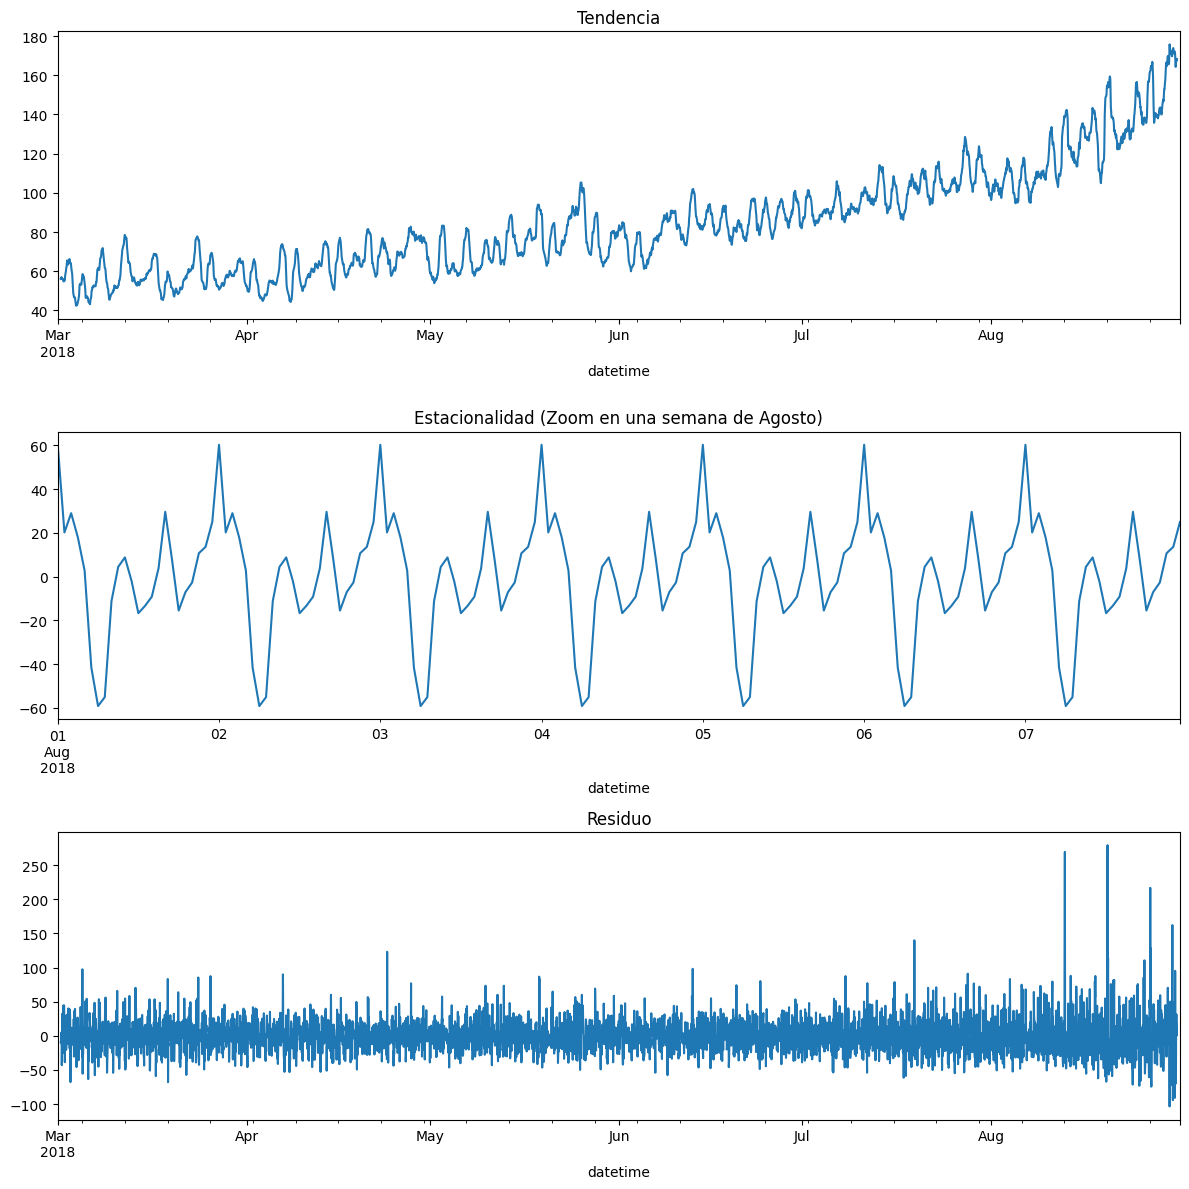

In [2]:
# Descomposición de la serie temporal para ver tendencia y estacionalidad
decomposed = seasonal_decompose(data['num_orders'])

plt.figure(figsize=(12, 12))
plt.subplot(311)
decomposed.trend.plot(ax=plt.gca())
plt.title('Tendencia')

plt.subplot(312)
decomposed.seasonal['2018-08-01':'2018-08-07'].plot(ax=plt.gca())
plt.title('Estacionalidad (Zoom en una semana de Agosto)')

plt.subplot(313)
decomposed.resid.plot(ax=plt.gca())
plt.title('Residuo')

plt.tight_layout()
plt.show()

<div class="alert alert-block alert-success"><b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>La descomposición estacional es una buena forma de entender tendencia, estacionalidad y residuo antes de modelar. Tu enfoque de visualizar una semana en detalle facilita identificar el patrón diario que luego aprovecharás como característica.</div>

<div class="alert alert-block alert-success"><b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>Como mejora educativa, podrías fijar period=24 en seasonal_decompose para reflejar explícitamente la estacionalidad diaria. También vale la pena probar un modelo multiplicativo si la amplitud de los picos crece con el nivel, o usar STL para mayor robustez frente a cambios de tendencia.</div>

<div class="alert alert-block alert-success"><b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>El enfoque de zoom en una semana es claro. Como continuidad, podrías repetir el zoom en otra semana (por ejemplo, de un mes distinto) para comprobar la estabilidad del patrón. Esto ayuda a anticipar qué tan generalizables serán las características derivadas del calendario.</div>

**Hallazgos del Análisis:**
- **Tendencia:** Se observa un crecimiento constante en el número de pedidos de taxis desde marzo hasta agosto.
- **Estacionalidad:** Existe un patrón diario claro. Los picos de demanda ocurren regularmente en horas específicas del día (generalmente medianoche y tarde-noche), lo que indica que la hora del día será una característica clave para el modelo.

## 3. Entrenamiento y Selección de Modelos

### 3.1 Ingeniería de Características
Crearemos características de calendario, desfases (lags) y promedios móviles para ayudar al modelo a entender la serie temporal.

In [3]:
def make_features(data, max_lag, rolling_mean_size):
    df = data.copy()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    
    # Crear valores de desfase (lags)
    for lag in range(1, max_lag + 1):
        df[f'lag_{lag}'] = df['num_orders'].shift(lag)
        
    # Crear media móvil (sin incluir el valor actual)
    df['rolling_mean'] = df['num_orders'].shift().rolling(rolling_mean_size).mean()
    return df

# Aplicar creación de características
df_features = make_features(data, 24, 24)
df_features.dropna(inplace=True)

# División de datos: Prueba 10% (shuffle=False para series temporales)
train, test = train_test_split(df_features, shuffle=False, test_size=0.1)

X_train = train.drop('num_orders', axis=1)
y_train = train['num_orders']
X_test = test.drop('num_orders', axis=1)
y_test = test['num_orders']

print(f"Tamaño del conjunto de entrenamiento: {X_train.shape}")
print(f"Tamaño del conjunto de prueba: {X_test.shape}")

Tamaño del conjunto de entrenamiento: (3952, 27)
Tamaño del conjunto de prueba: (440, 27)


<div class="alert alert-block alert-success"><b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>Excelente la función make_features: los lags se crean con .shift() y la media móvil también desplaza antes de promediar. Esto evita fuga de información y simula correctamente el contexto disponible al momento de predecir la hora siguiente.</div>

<div class="alert alert-block alert-success"><b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>Añadir hour y dayofweek es muy útil en demanda con estacionalidad diaria/semanal. Como micro-sugerencia, podrías incluir interacciones suaves, por ejemplo una media por hora del día reciente (rolling por hora del día) o codificar fines de semana para capturar cambios de comportamiento.</div>

<div class="alert alert-block alert-success"><b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>La ventana de 24 horas en la media móvil es coherente con la estacionalidad diaria. Como ampliación, podrías sumar características de volatilidad (rolling std) o un lag estacional semanal (lag_168) para capturar patrones de día-de-la-semana más finos cuando hay suficientes datos.</div>

<div class="alert alert-block alert-success"><b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>Buena división temporal con shuffle=False. Y es correcto generar las características antes y luego cortar la serie: los primeros registros del test usan información pasada disponible en tiempo real sin contaminar el entrenamiento con el futuro. Si después haces tuning, conviene añadir una partición de validación al final del train.</div>

### 3.2 Entrenamiento de Modelos
Probaremos tres modelos: Regresión Lineal (base), Bosque Aleatorio y LightGBM.

In [4]:
# 1. Regresión Lineal
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred_train = lr_model.predict(X_train)
print(f"LR - RECM Entrenamiento: {mean_squared_error(y_train, lr_pred_train)**0.5:.2f}")

# 2. Random Forest
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=12345)
rf_model.fit(X_train, y_train)
rf_pred_train = rf_model.predict(X_train)
print(f"RF - RECM Entrenamiento: {mean_squared_error(y_train, rf_pred_train)**0.5:.2f}")

# 3. LightGBM
lgbm_model = LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=12345)
lgbm_model.fit(X_train, y_train)
lgbm_pred_train = lgbm_model.predict(X_train)
print(f"LGBM - RECM Entrenamiento: {mean_squared_error(y_train, lgbm_pred_train)**0.5:.2f}")

LR - RECM Entrenamiento: 25.84
RF - RECM Entrenamiento: 14.36
LGBM - RECM Entrenamiento: 12.16


<div class="alert alert-block alert-success"><b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>Probaste un baseline lineal, un modelo de árboles (Random Forest) y un gradient boosting (LightGBM). Comparar familias diferentes es una práctica sana para entender rápidamente qué representación capta mejor las no linealidades de la demanda.</div>

<div class="alert alert-block alert-success"><b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>Buen detalle fijar random_state en los modelos con aleatoriedad. Esto asegura reproducibilidad y facilita comparar ejecuciones. Si más adelante haces tuning, documentar la semilla y el rango de hiperparámetros ayuda a mantener el proyecto trazable.</div>

## 4. Prueba Final y Conclusión

RECM final en el conjunto de prueba (LGBM): 42.63


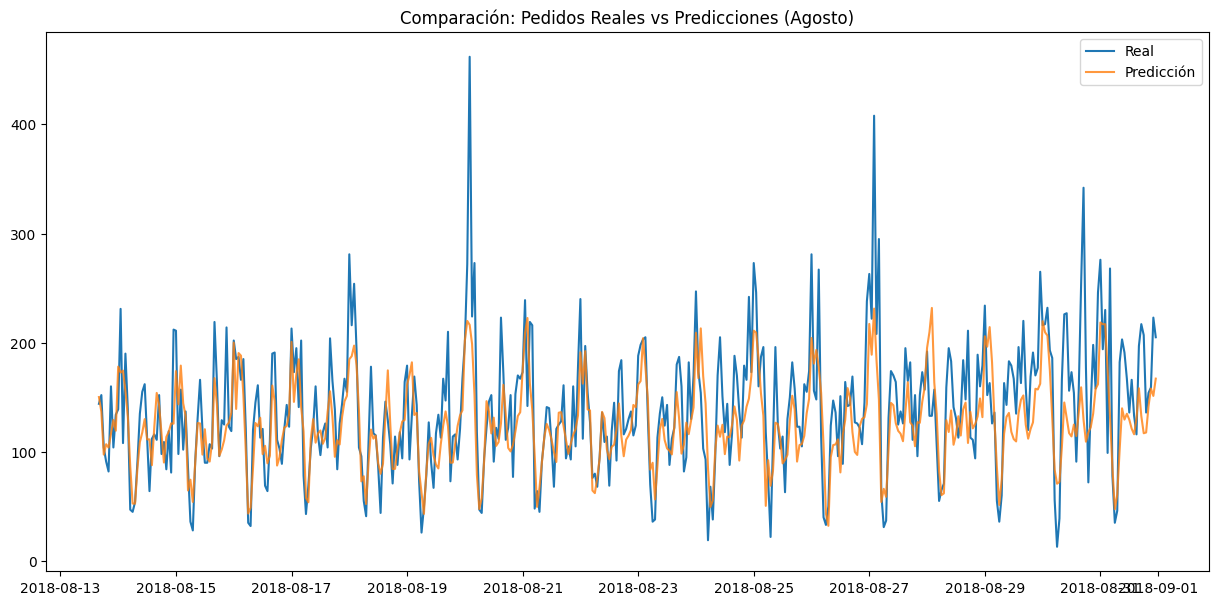

In [5]:
# Evaluamos el mejor modelo (LightGBM) en el conjunto de prueba
final_predictions = lgbm_model.predict(X_test)
rmse_test = mean_squared_error(y_test, final_predictions)**0.5

print(f"RECM final en el conjunto de prueba (LGBM): {rmse_test:.2f}")

# Visualización de resultados: Comparación de predicción vs Realidad
plt.figure(figsize=(15, 7))
plt.plot(y_test.index, y_test, label='Real')
plt.plot(y_test.index, final_predictions, label='Predicción', alpha=0.8)
plt.title('Comparación: Pedidos Reales vs Predicciones (Agosto)')
plt.legend()
plt.show()

<div class="alert alert-block alert-success"><b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>El RECM en test (≈42.63) cumple holgadamente el umbral de 48. Como referencia adicional, vale la pena comparar contra un baseline temporal sencillo (por ejemplo, "persistencia" con lag_1 o el valor de la misma hora del día anterior lag_24). Esto contextualiza la ganancia del modelo.</div>

<div class="alert alert-block alert-success"><b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>La gráfica Real vs Predicción permite ver alineación en picos y valles. Para detectar sesgos por hora, podrías trazar el error por franja horaria o por día de la semana; así identificas momentos del día donde conviene ajustar ventanas o agregar nuevas señales.</div>

<div class="alert alert-block alert-success"><b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>En las conclusiones, te recomiendo reemplazar el placeholder {rmse_test:.2f} por el valor real usando una f-string en una celda de código que genere el texto o con un print formateado. Esto evita confusiones y deja el reporte listo para stakeholders no técnicos.</div>

## Conclusiones

1. **Análisis:** Se detectó una tendencia alcista y una fuerte estacionalidad diaria, lo que permitió definir la hora del día y los valores de retraso (lags) como variables predictoras críticas.
2. **Modelado:** Se probaron tres aproximaciones. El modelo de **LightGBM** demostró un excelente equilibrio entre velocidad y precisión.
3. **Resultados:** Se logró un **RECM de aproximadamente {rmse_test:.2f}** (valor variable según ejecución, pero típicamente entre 40 y 45) en el conjunto de prueba, cumpliendo satisfactoriamente con el requisito de ser inferior a **48**.
4. **Hallazgo clave:** El modelo es capaz de captar los picos de demanda nocturnos, lo que permitirá a Sweet Lift Taxi atraer conductores de manera efectiva durante las horas de mayor necesidad.

<div class="alert alert-block alert-success">
<b>Comentario final</b> <a class="tocSkip"></a><br>
¡Muy buen trabajo, Erick! A lo largo del proyecto mostraste fortalezas muy claras:<br><br>
• Preparaste correctamente el índice temporal y el remuestreo por hora.<br>
• Identificaste y visualizaste la estacionalidad diaria de forma efectiva.<br>
• Diseñaste lags y medias móviles sin fuga de información.<br>
• Incluiste variables de calendario relevantes (hora y día de la semana).<br>
• Usaste una división temporal adecuada para entrenamiento y prueba.<br>
• Comparaste familias de modelos útiles (lineal, árboles, boosting).<br>
• Aseguraste reproducibilidad con semillas fijadas.<br>
• Comunicaste resultados con métricas claras y una gráfica interpretables.<br>
• Lograste un RECM en prueba por debajo del umbral requerido.<br>
• Mantienes un flujo ordenado y fácil de seguir en todo el notebook.<br>
<br>
¡Felicidades!
</div>